In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import analysis
import scipy.stats
import matplotlib.pyplot as plt
import RL

In [20]:
ids_fn = ['ak', 'bj', 'ts', 'ln_fn', 'mc_fn', 'em']
theta = [0.7, 15, 0.9]
N = 50 # the number of times we re run each individuals model

## recorded data
# rl model choices
# sr model choices
# human choices

# rl model accuracy to human when trained on data
# sr model accuracy to human when trained on data



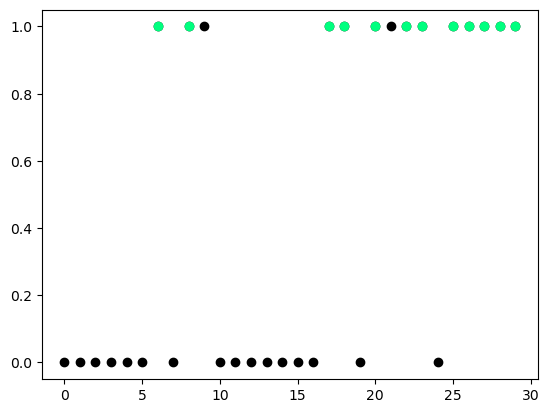

In [4]:
## Sample human behavioural data
sample_choices_h = np.load(r"C:\Users\newtc\OneDrive\Desktop\WIN 26\NEUSCI 403\task_demo\bj\choicedata_0.6_10_0.npy", allow_pickle=True)
sample_rds_h = np.load(r"C:\Users\newtc\OneDrive\Desktop\WIN 26\NEUSCI 403\task_demo\bj\reward_0.6_10_0.npy", allow_pickle=True)
correct_feature = (1,0)
choices = np.zeros(len(sample_choices_h))
for t in range(len(choices)):
    # print(sample_choices_h[t,-1][correct_feature[0]])
    if sample_choices_h[t,-1][correct_feature[0]]==correct_feature[1]:
        choices[t] = 1

plt.plot(np.arange(len(choices)), choices, 'o', color='k', label='unrewarded')
rewarded = np.argwhere(sample_rds_h)
plt.plot(rewarded, np.ones(len(rewarded)), 'o', color='springgreen', label='rewarded')
# print([1, 1, 1] == [1, 0, 3])

In [5]:
## Running RL model on task
def gen_features():
    INDEX = np.array([0, 1, 2, 3])
    stimuli_options = np.array([np.random.permutation(INDEX),  # color
                                    np.random.permutation(INDEX),  # shape
                                    np.random.permutation(INDEX)]) # pattern
    return stimuli_options.T

def run_RL(theta, p):
    alpha, beta, gamma = theta
    N=100
    task_accuracy = np.zeros(N) # 1 if model selects correct feature
    rewards = np.zeros(N)       # 1 if model was rewarded by env
    # create agent
    test_agent = RL.FeatureRLDecay(alpha, beta, gamma)
    correct = (np.random.randint(0,3), np.random.randint(0,4))
    prev_cor=0

    for k in range(N):
        test_agent.set_action(gen_features())

        test_agent.set_q()

        a_k_idx = test_agent.select_stim()
  
        if test_agent.actions[a_k_idx][correct[0]] == correct[1]:
            task_accuracy[k] = 1
            prev_cor+=1
            if np.random.random() < p:
                rewards[k] = 1
                test_agent.update_v(a_k_idx, 1)
                # print("Rewarded!")
            else:
                test_agent.update_v(a_k_idx, 0)
        else:
            test_agent.update_v(a_k_idx, 0)
            prev_cor = 0
        # print("V-table after update: " + str(test_agent.v_feature))
        # print("New Choice!")
        if prev_cor >= 5:
            task_accuracy = task_accuracy[:k+1]
            return task_accuracy, rewards[:k+1]
    return N


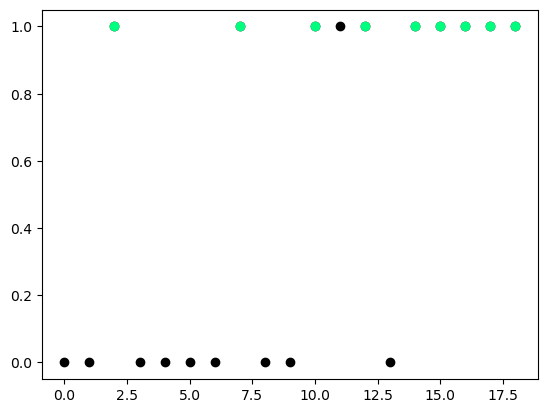

In [6]:
## Sample RL model solving this task
choices_rl, rewards_rl = run_RL(theta, 0.6)

plt.plot(np.arange(len(choices_rl)), choices_rl, 'o', color='k', label='unrewarded')
rewarded = np.argwhere(rewards_rl)
plt.plot(rewarded, np.ones(len(rewarded)), 'o', color='springgreen', label='rewarded')

In [7]:
## Sample SR model solving this task
def run_SR(p):
    N=100
    task_accuracy = np.zeros(N) # 1 if model selects correct feature
    rewards = np.zeros(N)       # 1 if model was rewarded by env

    ## set up stimulus response 
    stimuli = np.zeros(64, dtype=tuple)
    for col in range(4):
        for shape in range(4):
            for pat in range(4):
                stimuli[int(16*col + 4*shape + pat)] = (col, shape, pat)
    sr_dict = {stimuli[i] : 0 for i in range(64)}
    correct = (np.random.randint(0,3), np.random.randint(0,4))
    prev_cor=0

    for t in range(N):
        env = gen_features()
        # extract associ of options
        vals = np.array([sr_dict[tuple(env[0])], sr_dict[tuple(env[1])], 
                                sr_dict[tuple(env[2])], sr_dict[tuple(env[3])]])
        if np.sum(vals) == 0:
            p_a = np.ones(4)*0.25
        else:
            p_a = vals / np.sum(vals)
        a_k_idx = np.random.choice(list(range(4)), p=p_a)
        a_k = env[a_k_idx]

        if a_k[correct[0]] == correct[1]:
            task_accuracy[t] = 1
            prev_cor += 1
            if np.random.random() < p:
                rewards[t] = 1
                sr_dict[tuple(a_k)] += 50
        else:
            prev_cor = 0
        if prev_cor >= 5:
            task_accuracy = task_accuracy[:t+1]
            return task_accuracy, rewards[:t+1]

    return N


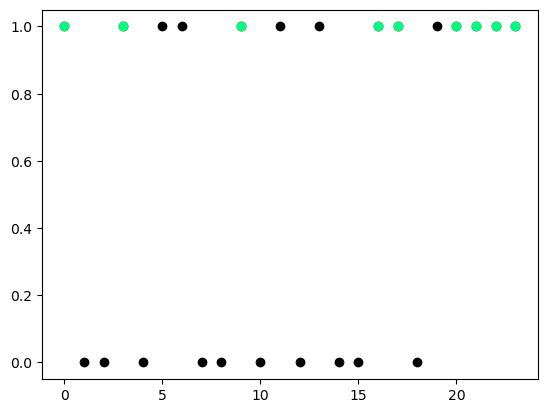

In [9]:
## Sample SR model solving this task
choices_sr, rewards_sr = run_SR(0.6)

plt.plot(np.arange(len(choices_sr)), choices_sr, 'o', color='k', label='unrewarded')
rewarded = np.argwhere(rewards_sr)
plt.plot(rewarded, np.ones(len(rewarded)), 'o', color='springgreen', label='rewarded')

In [ ]:
# train hyperparameters using naive grid search with narrowing?

In [25]:
## rl and sr model predictive of human behaviour on false negatives
p_levels = [0.6, 0.8, 1.]
n_p = 3 # how many p_levels; usually 3 for 0.6,0.8,1.
N=50 # how many times we simulate each person's data
acc_rl = np.zeros((N*len(ids_fn), n_p))
acc_sr = np.zeros((N*len(ids_fn), n_p))

for i, id in enumerate(ids_fn):
    px = analysis.Subject(id, np.array(p_levels))
    px._set_params(theta[0], theta[1], theta[2])
    for k in range(N):
        acc_k_rl = px.predict_RL()
        acc_k_sr = px.predict_SA()
        for p in range(n_p):
            acc_rl[N*i + k, p] = sum(acc_k_rl[p]) / len(acc_k_rl[p])
            acc_sr[N*i + k, p] = sum(acc_k_sr[p]) / len(acc_k_sr[p])

Text(0, 0.5, 'Model Predictive Accuracy')

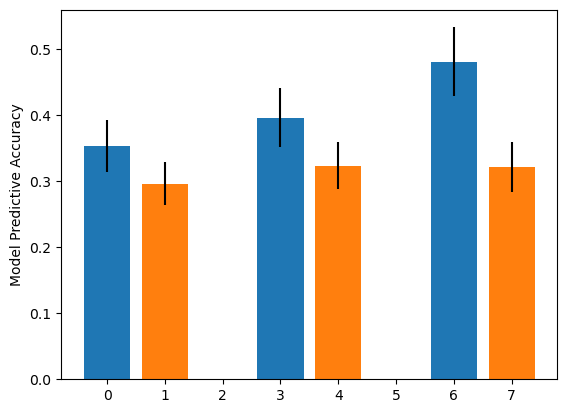

In [24]:
fig, ax = plt.subplots()
ax.bar(list(range(0,9,3)), np.mean(acc_rl, axis=0))
ax.bar(list(range(1, 10, 3)),  np.mean(acc_sr, axis=0))

ax.errorbar(list(range(0,9,3)), np.mean(acc_rl, axis=0), yerr=np.std(acc_rl, axis=0), 
             linestyle="", color='k')
ax.errorbar(list(range(1, 10, 3)), np.mean(acc_sr, axis=0), yerr=np.std(acc_sr, axis=0), 
             linestyle="", color='k')
ax.set_ylabel("Model Predictive Accuracy")

In [29]:
## rl and sr model predictive of human behaviour on false negatives and false positives
ids_fn = ['bj_fp', 'ts_fp']
p_levels = [0.6, 0.85]
n_p = 2 # how many p_levels; usually 3 for 0.6,0.8,1.
N=50 # how many times we simulate each person's data
acc_rl = np.zeros((N*len(ids_fn), n_p))
acc_sr = np.zeros((N*len(ids_fn), n_p))

for i, id in enumerate(ids_fn):
    px = analysis.Subject(id, np.array(np.array(p_levels)))
    px._set_params(theta[0], theta[1], theta[2])
    for k in range(N):
        acc_k_rl = px.predict_RL()
        acc_k_sr = px.predict_SA()
        for p in range(n_p):
            acc_rl[N*i + k, p] = sum(acc_k_rl[p]) / len(acc_k_rl[p])
            acc_sr[N*i + k, p] = sum(acc_k_sr[p]) / len(acc_k_sr[p])

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
fig, ax = plt.subplots()
ax.bar(list(range(0,9,3)), np.mean(acc_rl, axis=0))
ax.bar(list(range(1, 10, 3)),  np.mean(acc_sr, axis=0))

ax.errorbar(list(range(0,9,3)), np.mean(acc_rl, axis=0), yerr=np.std(acc_rl, axis=0), 
             linestyle="", color='k')
ax.errorbar(list(range(1, 10, 3)), np.mean(acc_sr, axis=0), yerr=np.std(acc_sr, axis=0), 
             linestyle="", color='k')
ax.set_ylabel("Model Predictive Accuracy")